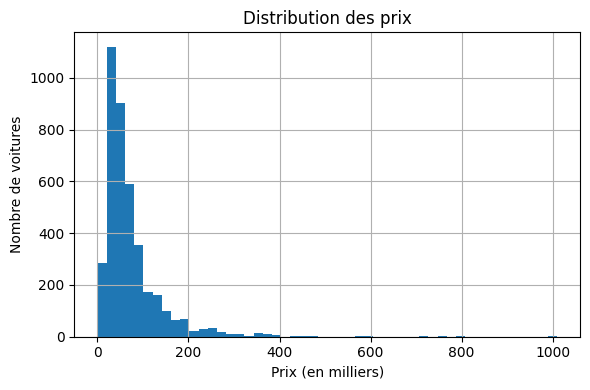

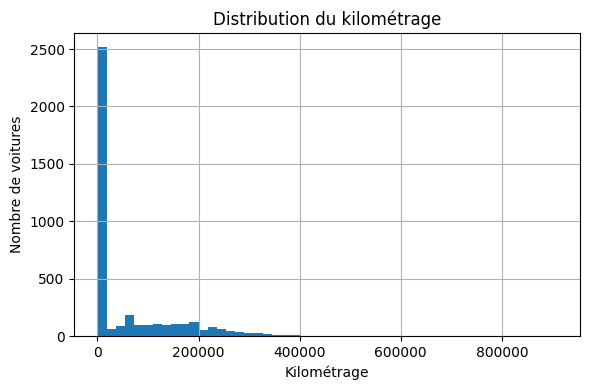

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Car-Data-Occasion-Clean-5.csv")

# Histogramme des prix (en milliers)
plt.figure(figsize=(6,4))
(df["Prix"] / 1000).hist(bins=50)
plt.xlabel("Prix (en milliers)")
plt.ylabel("Nombre de voitures")
plt.title("Distribution des prix")
plt.tight_layout()
plt.show()

# Histogramme du kilométrage
plt.figure(figsize=(6,4))
df["Kilometrage"].hist(bins=50)
plt.xlabel("Kilométrage")
plt.ylabel("Nombre de voitures")
plt.title("Distribution du kilométrage")
plt.tight_layout()
plt.show()


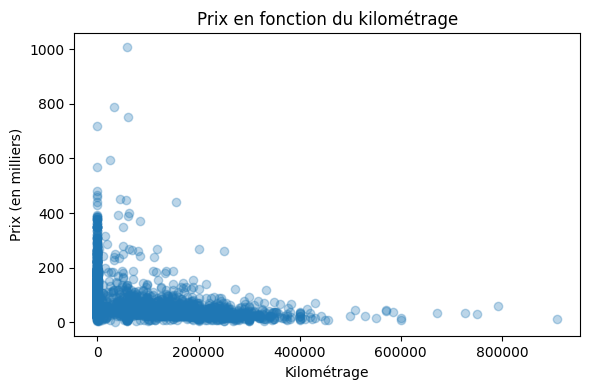

In [3]:
plt.figure(figsize=(6,4))
plt.scatter(df["Kilometrage"], df["Prix"] / 1000, alpha=0.3)
plt.xlabel("Kilométrage")
plt.ylabel("Prix (en milliers)")
plt.title("Prix en fonction du kilométrage")
plt.tight_layout()
plt.show()


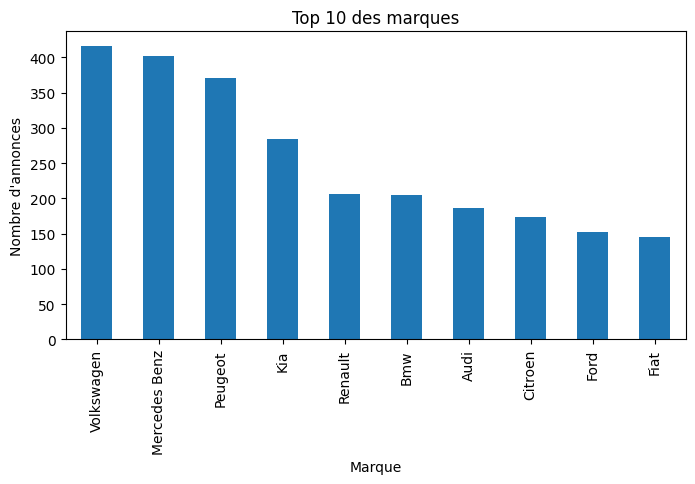

In [4]:
top_marques = df["Marque"].value_counts().head(10)

plt.figure(figsize=(8,4))
top_marques.plot(kind="bar")
plt.xlabel("Marque")
plt.ylabel("Nombre d'annonces")
plt.title("Top 10 des marques")
plt.show()


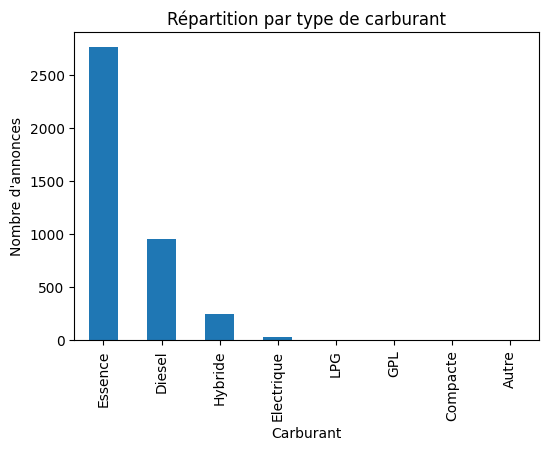

In [6]:
plt.figure(figsize=(6,4))
df["Carburant"].value_counts().plot(kind="bar")
plt.xlabel("Carburant")
plt.ylabel("Nombre d'annonces")
plt.title("Répartition par type de carburant")
plt.show()


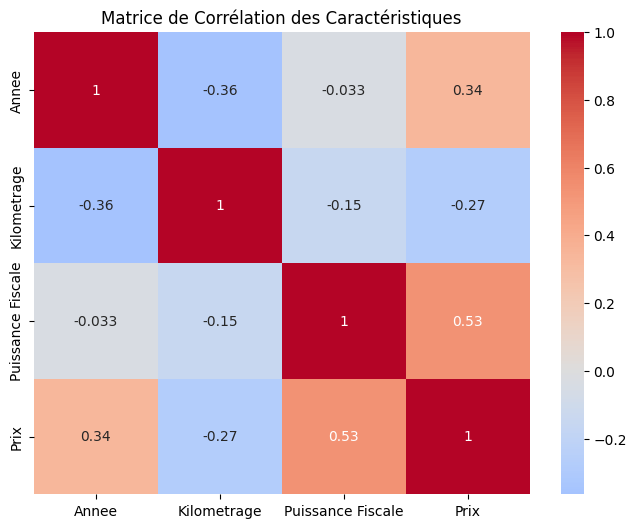

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = ['Annee', 'Kilometrage', 'Puissance Fiscale', 'Prix']
corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de Corrélation des Caractéristiques")
plt.show()



In [24]:
import pandas as pd

# Arrondir pour l'affichage
desc_num = df[["Annee", "Kilometrage", "Puissance Fiscale", "Prix"]].describe().round(2)
desc_cat = df[["Marque", "Modele", "Carburant", "Boite Vitesse", "Etat Generale"]].describe()

print("=== Statistiques numériques ===")
display(desc_num)

print("=== Statistiques catégorielles ===")
display(desc_cat)

print("=== Statistiques de la variable cible (Prix) ===")
display(df["Prix"].describe().round(2).to_frame().T)


=== Statistiques numériques ===


,Annee,Kilometrage,Puissance Fiscale,Prix
count,3993.00,3993.00,3993.00,3993.00
mean,2016.19,58857.15,7.43,72399.08
std,6.24,97881.09,3.79,66086.70
min,1982.00,1.00,4.00,135.00
25%,2013.00,99.00,5.00,34500.00
50%,2018.00,208.00,7.00,52000.00
75%,2021.00,98000.00,8.00,85000.00
max,2025.00,909099.00,48.00,1009317.00


=== Statistiques catégorielles ===


,Marque,Modele,Carburant,Boite Vitesse,Etat Generale
count,3993,3993,3993,3993,3993
unique,64,596,8,2,2
top,Volkswagen,Classe C,Essence,Manuelle,occasion
freq,416,121,2767,2274,2236


=== Statistiques de la variable cible (Prix) ===


,count,mean,std,min,25%,50%,75%,max
Prix,3993.0,72399.08,66086.7,135.0,34500.0,52000.0,85000.0,1009317.0


In [25]:
import pandas as pd

df = pd.read_csv("Car-Data-Occasion.csv")

# Nombre de valeurs manquantes par colonne
missing_counts = df.isna().sum()
print("=== Valeurs manquantes par colonne ===")
print(missing_counts)

# Pour aussi voir le pourcentage
missing_percent = (df.isna().sum() / len(df)) * 100
print("\n=== Pourcentage de valeurs manquantes ===")
print(missing_percent.round(2))


=== Valeurs manquantes par colonne ===
Marque                0
Modele                0
Annee                14
Kilometrage          36
Carburant             3
Boite Vitesse         3
Puissance Fiscale    17
Nombre Portes        41
Etat Generale         0
Prix                  0
dtype: int64

=== Pourcentage de valeurs manquantes ===
Marque               0.00
Modele               0.00
Annee                0.33
Kilometrage          0.85
Carburant            0.07
Boite Vitesse        0.07
Puissance Fiscale    0.40
Nombre Portes        0.97
Etat Generale        0.00
Prix                 0.00
dtype: float64


In [26]:
# Nombre total de lignes dupliquées (toutes colonnes identiques)
dup_total = df.duplicated().sum()
print("\nNombre de doublons (toutes colonnes):", dup_total)

# Si tu veux les voir
dup_rows = df[df.duplicated(keep=False)]
# display(dup_rows)  # dans Jupyter



Nombre de doublons (toutes colonnes): 66


In [27]:
nb_prix_zero = (df["Prix"] == 0).sum()
print("Nombre de lignes avec Prix = 0 :", nb_prix_zero)

lignes_prix_zero = df[df["Prix"] == 0]

Nombre de lignes avec Prix = 0 : 161


In [30]:
df = pd.read_csv("Car-Data-Occasion.csv")

# 1) S'assurer que Kilometrage est bien numérique
df["Kilometrage"] = (
    df["Kilometrage"]
    .astype(str)
    .str.replace(" ", "", regex=False)   # si jamais il reste des espaces
    .replace("N/A", np.nan)
)
df["Kilometrage"] = pd.to_numeric(df["Kilometrage"], errors="coerce")

# 3) km incohérent (<= 0)
nb_km_incoh = (df["Kilometrage"] <= 0).sum()
print("Nombre de lignes avec km incohérent (<= 0) :", nb_km_incoh)


Nombre de lignes avec km incohérent (<= 0) : 49


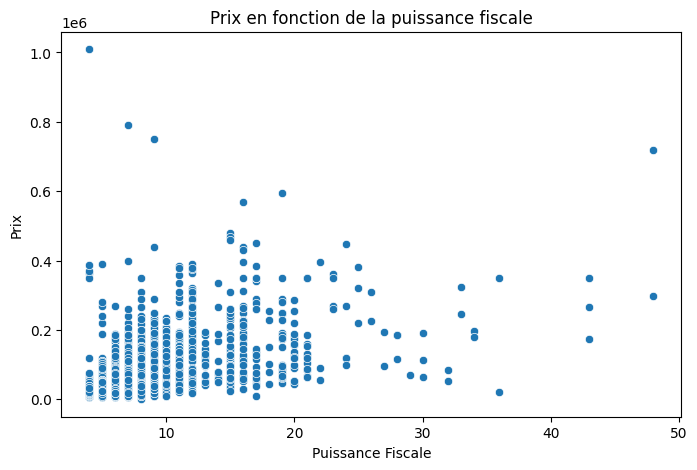

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Puissance Fiscale", y="Prix")
plt.title("Prix en fonction de la puissance fiscale")
plt.show()
